# Appendix C: Measurement circuit & factorization check

Generates two figures:
1) Clean measurement signal $V_m$ (perfect preparation) vs $|\alpha|$ with alpha-specific points at $|\alpha|=n_q, n_q/2, 3n_q/4$ and stretched-exponential fits for $|\alpha|=n_q$.
2) Predicted vs simulated $V_Q$ including preparation error, using `data/noisy_data/` and the prediction pipeline from `data/vdevice_curves_full.json`.


In [17]:
import json
import glob
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# Repo root (works whether you run from the root or inside figures_notebooks/)
cwd = Path.cwd()
REPO_ROOT = cwd.parent if cwd.name == 'figures_notebooks' else cwd

plt.style.use(str(REPO_ROOT / 'figures_notebooks' / 'single_column.mplstyle'))

DATA_DIR = REPO_ROOT / 'data'
FIG4_RAW = DATA_DIR / 'fig4_clean_raw_stats.json'
FIG4_VM_FITS_BY_ALPHA = {
    # Bare V_m grids (no readout correction); raw scatter still from measured accuracies
    'nq': DATA_DIR / 'fig4_clean_m_vm_grids_nq.json',
    'nq/2': DATA_DIR / 'fig4_clean_m_vm_grids_nq2.json',
}
VDEVICE_CURVES = DATA_DIR / 'vdevice_curves_full.json'
NOISY_DATA_DIR = DATA_DIR / 'noisy_data'

def lighten_color(color, amount_to_white=0.35):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    return tuple(rgb * (1 - amount_to_white) + white * amount_to_white)

def stretched_vm_from_fit(a, c, x):
    """Schema in fig4_clean_m_vm_grids_nq*.json: V = exp(-a * x**c)."""
    x = np.asarray(x, dtype=float)
    return np.exp(-a * (x ** c))



Bad key axes.grid.alpha in file /Users/krzywdaja/Documents/noisy-learning-advantage/figures_notebooks/single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


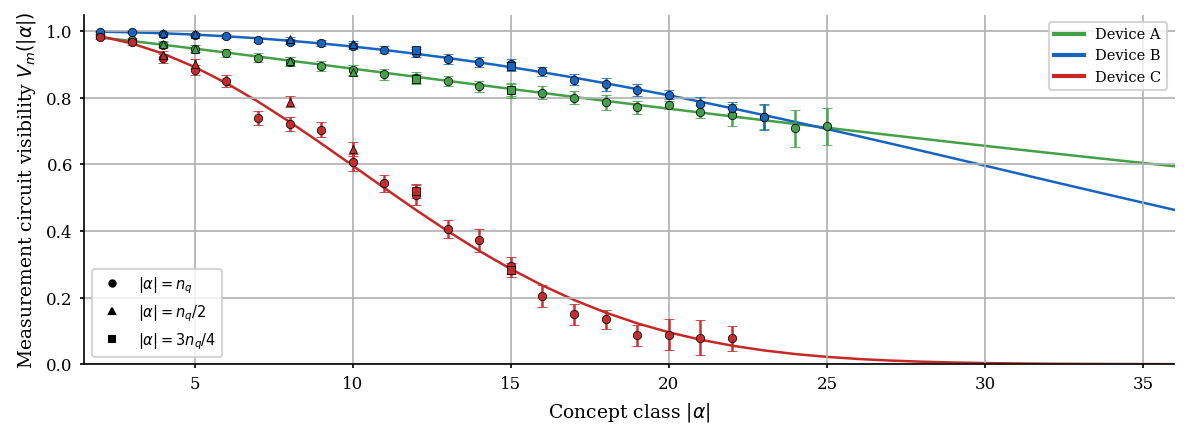

In [22]:
# --------------------------------
# Figure 1: Measurement circuit (perfect preparation)
# --------------------------------

with open(FIG4_RAW) as f:
    raw = json.load(f)

vm_fits_by_alpha = {}
for _alpha_key, _path in FIG4_VM_FITS_BY_ALPHA.items():
    with open(_path) as f:
        vm_fits_by_alpha[_alpha_key] = json.load(f)

raw_stats = raw['raw_stats']

# Device A/B/C: same palette as figures_notebooks/fig2_quantum.ipynb (green / blue / red)
device_colors = {'A': '#43A047', 'B': '#1565C0', 'C': '#C62828'}

alpha_patterns = {
    'nq': {'label': r'$|\alpha|=n_q$', 'marker': 'o'},
    'nq/2': {'label': r'$|\alpha|=n_q/2$', 'marker': '^'},
    '3/4nq': {'label': r'$|\alpha|=3n_q/4$', 'marker': 's'},
}

fig, ax = plt.subplots(figsize=(8, 3))

# Stretched-exponential fits from alpha-specific V_m grids (no readout correction in the fit JSON)
for dev in ['A', 'B', 'C']:
    for alpha_key in ['nq']:
        fit_source = vm_fits_by_alpha[alpha_key]
        fit = fit_source['exports'][dev]['fit_model']
        a = fit['a']
        c = fit['c']
        nq_grid = np.array(fit_source['exports'][dev]['nq_grid'], dtype=float)

        # Prompt: show the stretched-exponential fit up to nq=50.
        x_fit = nq_grid[nq_grid <= 50]
        y_fit = stretched_vm_from_fit(a, c, x_fit)

        if alpha_key == 'nq':
            x_alpha = x_fit
        else:
            x_alpha = x_fit / 2.0

        ax.plot(x_alpha, y_fit, color=device_colors[dev], lw=1.2, ls='-', zorder=1)

# Raw points (SEM error bars: std/sqrt(count))
for dev in ['A', 'B', 'C']:
    color = device_colors[dev]
    for pat_key, pat_meta in alpha_patterns.items():
        points = raw_stats[dev].get(pat_key, {})
        if not points:
            continue

        nq_vals = np.array(sorted(map(float, points.keys())), dtype=float)
        means_acc = np.array([points[str(int(nq))]['mean'] for nq in nq_vals], dtype=float)
        stds_acc = np.array([points[str(int(nq))]['std'] for nq in nq_vals], dtype=float)
        counts = np.array([points[str(int(nq))]['count'] for nq in nq_vals], dtype=float)

        # Map nq -> |alpha| positions exactly as requested.
        if pat_key == 'nq':
            x = nq_vals
        elif pat_key == 'nq/2':
            x = nq_vals / 2.0
        elif pat_key == '3/4nq':
            x = 3.0 * nq_vals / 4.0
        else:
            raise ValueError(pat_key)

        # Convert measured average accuracy to visibility: acc = 1/2 + 1/2 * vis.
        # => vis = 2*acc - 1, and uncertainties scale by the same factor.
        means = 2.0 * means_acc - 1.0
        yerr = 2*stds_acc 
        ax.errorbar(
            x,
            means,
            yerr=yerr,
            fmt=pat_meta['marker'],
            color=color,
            ecolor=color,
            elinewidth=1.2,
            capsize=2.5,
            markersize=4,
            markeredgecolor='black',
            markeredgewidth=0.4,
            zorder=2,
            alpha=0.95,
        )

# Legends
device_handles = [Line2D([0], [0], color=device_colors[d], lw=2.0, label=f'Device {d}') for d in ['A', 'B', 'C']]
alpha_handles = [
    Line2D([0], [0], color='k', marker=alpha_patterns[k]['marker'], ls='None', label=alpha_patterns[k]['label'])
    for k in ['nq', 'nq/2', '3/4nq']
]

leg1 = ax.legend(handles=device_handles, loc='upper right', fontsize=7, frameon=True)
ax.add_artist(leg1)
ax.legend(handles=alpha_handles,  loc='lower left', fontsize=7, frameon=True)

ax.set_xlabel(r'Concept class $|\alpha|$')
ax.set_ylabel(r'Measurement circuit visibility $V_m(|\alpha|)$')
ax.set_ylim(0.0, 1.05)
ax.set_xlim(1.5, 36.0)

plt.tight_layout()
plt.savefig("figures_app/app_c2_vm.pdf")


### Notes
- Stretched-exponential curves use $V_m(x)=\exp(-a x^{c})$ from `fig4_clean_m_vm_grids_nq.json` for $|\alpha|=n_q$ and `fig4_clean_m_vm_grids_nq2.json` for $|\alpha|=n_q/2$ (bare $V_m$, no readout correction in the fit files).
- Point uncertainties use `std/sqrt(count)` from `fig4_clean_raw_stats.json`.

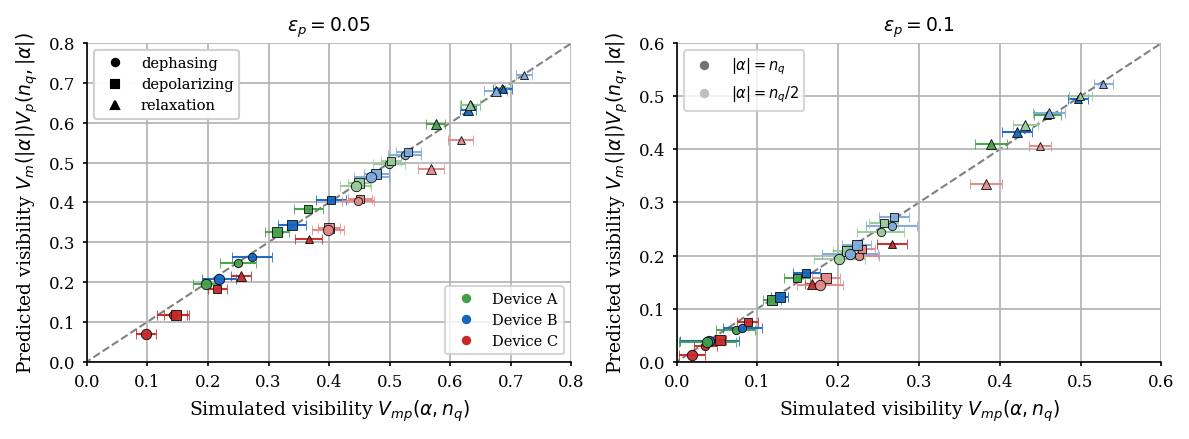

In [23]:
# --------------------------------
# Figure 2: Predicted vs simulated (with preparation error)
# --------------------------------

with open(VDEVICE_CURVES) as f:
    vdata = json.load(f)

nq_to_idx = {int(n): i for i, n in enumerate(vdata['nq_values'])}

# Match the device -> readout error selection used in fig2_quantum.ipynb
readout_by_device = {'I': '0.1%', 'T': '0.1%', 'S': '1%'}

# Map device letters (I/S/T) to A/B/C (same hex palette as fig2_quantum.ipynb)
device_letter_to_ABC = {'I': 'A', 'T': 'B', 'S': 'C'}
device_base_colors = {'A': '#43A047', 'B': '#1565C0', 'C': '#C62828'}

channel_marker = {'dephasing': 'o', 'depolarizing': 's', 'relaxation': '^'}
nq_marker_size = {12: 16, 14: 25}

def alpha_label_to_alpha_key(alpha_label: str) -> str:
    return 'nq' if alpha_label == 'nq' else 'nq/2'

def alpha_label_to_brightness(alpha_label: str) -> float:
    # Darker for |alpha|=nq, lighter for |alpha|=nq/2
    return 0.0 if alpha_label == 'nq' else 0.45

prep_amps = [0.05, 0.1]

meta_paths = glob.glob(str(NOISY_DATA_DIR / '*' / '*' / 'metadata.json'))

# Leaf folder format:
#   <DeviceLetter>_<channel>_nq<nq>_k<k>_<alpha_label>_amp<amp>
re_leaf = re.compile(r'(?P<dev>[ITS])_(?P<chan>[^_]+)_nq(?P<nq>\d+)_k(?P<k>\d+)_(?P<alpha>nq(?:_2)?)_amp(?P<amp>[0-9.]+)$')

# Group simulated samples by configuration
grouped = {}  # (dev, chan, nq, alpha_label, amp) -> list of simulated acc samples

for mp in meta_paths:
    leaf_dir = Path(mp).parent
    m = re_leaf.match(leaf_dir.name)
    if not m:
        continue

    dev = m.group('dev')
    chan = m.group('chan')
    nq = int(m.group('nq'))
    alpha_label = m.group('alpha')
    amp = float(m.group('amp'))

    if amp not in prep_amps:
        continue

    # Leaf folders contain f-chunks with names like f0to0, f12to15, etc.
    # Load all available chunks and flatten into a 1D sample list.
    acc_chunks = sorted(leaf_dir.glob('acc_optimized_final_f*.npy'))
    if not acc_chunks:
        acc_chunks = sorted(leaf_dir.glob(f'acc_optimized_nq{nq}_f*.npy'))
    if not acc_chunks:
        continue

    acc_vals = []
    for p in acc_chunks:
        arr = np.load(p)
        acc_vals.extend(np.asarray(arr, dtype=float).reshape(-1).tolist())

    key = (dev, chan, nq, alpha_label, amp)
    grouped.setdefault(key, []).extend(acc_vals)

# Build points for plotting
points_by_prep = {amp: [] for amp in prep_amps}
for (dev, chan, nq, alpha_label, amp), acc_list in grouped.items():
    acc_arr = np.array(acc_list, dtype=float)
    sim_mean_acc = float(acc_arr.mean())
    sim_std_acc = float(acc_arr.std(ddof=1)) if len(acc_arr) > 1 else 0.0
    sim_sem_acc = sim_std_acc  if len(acc_arr) > 0 else 0.0

    alpha_key = alpha_label_to_alpha_key(alpha_label)
    readout_key = readout_by_device[dev]

    # JSON key formatting (0.05 vs 0.1)
    prep_key = (f'{amp:.2f}').rstrip('0').rstrip('.')
    idx = nq_to_idx[nq]
    pred_series = vdata['curves'][dev][chan][alpha_key][readout_key][prep_key]
    pred_acc = float(pred_series[idx])

    # Convert accuracy -> visibility: V = 2*acc - 1
    sim_mean = 2.0 * sim_mean_acc - 1.0
    sim_sem = 2.0 * sim_sem_acc
    pred = 2.0 * pred_acc - 1.0

    points_by_prep[amp].append({
        'dev': dev,
        'chan': chan,
        'nq': nq,
        'alpha_label': alpha_label,
        'sim_mean': sim_mean,
        'sim_sem': sim_sem,
        'pred': pred,
    })

fig, axes = plt.subplots(1, len(prep_amps), figsize=(4 * len(prep_amps), 3), sharex=False, sharey=False)
if len(prep_amps) == 1:
    axes = [axes]

for i, (ax, amp) in enumerate(zip(axes, prep_amps)):
    ax.plot([-0.05, 1.0], [-0.05, 1.0], ls='--', color='0.5', lw=1.0, zorder=0)

    for pt in points_by_prep[amp]:
        dev_ABC = device_letter_to_ABC[pt['dev']]
        base_color = device_base_colors[dev_ABC]
        bright_amount = alpha_label_to_brightness(pt['alpha_label'])
        color = lighten_color(base_color, amount_to_white=bright_amount)

        marker = channel_marker[pt['chan']]
        msize = nq_marker_size.get(pt['nq'], 16)

        ax.errorbar(
            pt['sim_mean'],
            pt['pred'],
            xerr=pt['sim_sem'],
            yerr=None,
            fmt=marker,
            color=color,
            ecolor=color,
            elinewidth=1.0,
            capsize=2.5,
            markersize=np.sqrt(msize),
            markeredgecolor='black',
            markeredgewidth=0.4,
            alpha=0.95,
        )

    ax.set_title(rf'$\epsilon_p = {amp:g}$')
    ax.set_xlabel(r'Simulated visibility $V_{mp}(\alpha, n_q)$')
    ax.set_ylabel(r'Predicted visibility $V_m(|\alpha|) V_p(n_q, |\alpha|)$')
    if i == 1:
        ax.set_xlim(0.0, 0.6)
        ax.set_ylim(0.0, 0.6)
    else:
        ax.set_xlim(0.0, 0.8)
        ax.set_ylim(0.0, 0.8)

# Legends on the first axis
device_handles = [
    Line2D([0], [0], color=device_base_colors[d], marker='o', ls='None', label=f'Device {d}', markersize=3.5)
    for d in ['A', 'B', 'C']
]

channel_handles = [
    Line2D([0], [0], color='k', marker=channel_marker[ch], ls='None', label=ch, markersize=3.5)
    for ch in ['dephasing', 'depolarizing', 'relaxation']
]

# Gray alpha legend requested in the prompt (we show |alpha|=n_q vs n_q/2)
alpha_gray_handles = [
    Line2D([0], [0], color='0.45', marker='o', ls='None', label=r'$|\alpha|=n_q$', markersize=3.5),
    Line2D([0], [0], color='0.75', marker='o', ls='None', label=r'$|\alpha|=n_q/2$', markersize=3.5),
]

leg_dev = axes[0].legend(handles=device_handles,  loc='lower right', fontsize=7, frameon=True)
axes[0].add_artist(leg_dev)
leg_chan = axes[0].legend(handles=channel_handles,loc='upper left', fontsize=7, frameon=True)
axes[0].add_artist(leg_chan)
axes[1].legend(handles=alpha_gray_handles,loc='upper left', fontsize=7, frameon=True)

plt.tight_layout()
plt.savefig("figures_app/app_c2_vmp.pdf")



array([[9.97002000e-01, 9.96004998e-01, 9.95008993e-01, ...,
        9.48353914e-01, 9.47405560e-01, 9.46458154e-01],
       [9.96921162e-01, 9.95897342e-01, 9.94874573e-01, ...,
        9.46997252e-01, 9.46024702e-01, 9.45053152e-01],
       [9.96838147e-01, 9.95786789e-01, 9.94736540e-01, ...,
        9.45605964e-01, 9.44608640e-01, 9.43612369e-01],
       ...,
       [5.03031989e-01, 4.07642688e-01, 3.30341935e-01, ...,
        1.36709347e-05, 1.10785331e-05, 8.97772532e-06],
       [4.91615518e-01, 3.95875697e-01, 3.18780757e-01, ...,
        9.73393512e-06, 7.83829681e-06, 6.31182518e-06],
       [4.80000000e-01, 3.84000000e-01, 3.07200000e-01, ...,
        6.85078892e-06, 5.48063114e-06, 4.38450491e-06]])

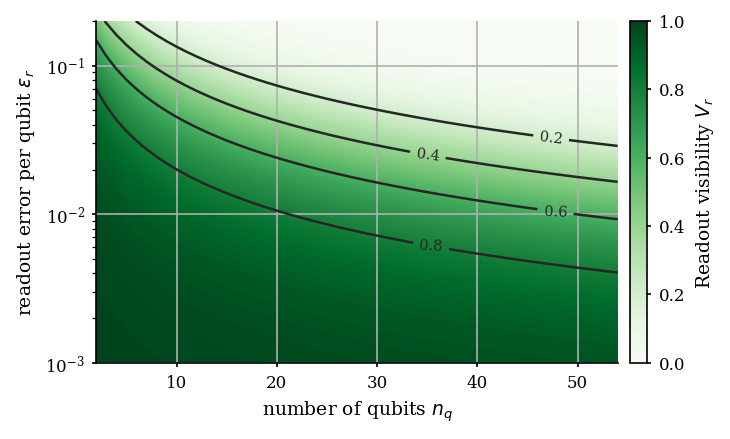

In [25]:

# --------------------------------
# Figure 3: 2D contour map of readout visibility V_r
# --------------------------------

# V_r(nq, eps_r) = (1 - 2*eps_r) * (1 - eps_r)^(nq - 1)
eps_r_min = 0.001
eps_r_max = 0.2

eps_r = np.logspace(np.log10(eps_r_min), np.log10(eps_r_max), 200)
nq_vals = np.arange(2, 55, dtype=float)

# Grid where X = n_q and Y = eps_r
NQ, EPS = np.meshgrid(nq_vals, eps_r)
V_r = (1.0 - 2.0 * EPS) * ((1.0 - EPS) ** (NQ - 1.0))

requested_levels = sorted([0.8, 0.6, 0.4, 0.2])
vmin = float(np.nanmin(V_r))
vmax = float(np.nanmax(V_r))
levels = [lv for lv in requested_levels if (vmin <= lv <= vmax)]
if not levels:
    levels = requested_levels

fig3, ax3 = plt.subplots(figsize=(5, 3))
ax3.set_facecolor('0.97')

# Background color: filled contours (log-scaled for readability)
vmin_plot = float(np.nanmin(V_r))
vmax_plot = float(np.nanmax(V_r))
cf = ax3.contourf(NQ, EPS, V_r, levels=101, cmap='Greens', vmin=vmin_plot, vmax=vmax_plot)
cs = ax3.contour(NQ, EPS, V_r, levels=levels, colors='0.15', linewidths=1.2)

cb = fig3.colorbar(cf, ax=ax3, pad=0.02)
cb.set_label(r'Readout visibility $V_r$')
cb.set_ticks([0,0.2, 0.4, 0.6, 0.8,1])
cb.ax.tick_params(labelsize=8)

ax3.clabel(cs, inline=True, fontsize=7, fmt=lambda x: f'{x:.1f}')

ax3.set_yscale('log')
ax3.set_xlabel(r'number of qubits $n_q$')
ax3.set_ylabel(r'readout error per qubit $\epsilon_r$')
ax3.set_xlim(float(nq_vals.min()), float(nq_vals.max()))
ax3.set_ylim(eps_r_min, eps_r_max)

plt.tight_layout()
plt.savefig("figures_app/app_c1_vr.pdf")

V_r
